# Brain Tumor Image Segmentation Using U-Net Architecture

This project implements a U-Net CNN for binary image segmentation.

**Key Design Decisions:**
- Custom focal-dice loss to handle class imbalance between foreground and background pixels
- Data augmentation (flips, rotations, etc) to improve generalization
- Adam optimizer with starting learning rate of 1e-4

## Importing Datasets

The dataset is loaded and split into training and validation sets. Images are resized to a fixed resolution and normalized. Masks are kept as single-channel binary maps where 1 indicates the target region and 0 indicates background.

In [42]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

In [2]:
import os
import numpy as np
import glob
import tensorflow as tf
from PIL import Image
from pycocotools.coco import COCO

IMG_SIZE = 256
BATCH_SIZE = 8

In [3]:
def build_arrays(split_dir):
    json_path = glob.glob(os.path.join(split_dir, "*.json"))[0]
    coco = COCO(json_path)
 
    images_out = []
    masks_out = []
 
    for img_id in coco.getImgIds():
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(split_dir, img_info["file_name"])
        if not os.path.exists(img_path):
            continue
 
        image = Image.open(img_path).convert("RGB")
        height, width = img_info["height"], img_info["width"]


        mask = np.zeros((height, width), dtype=np.uint8)
        ann_ids = coco.getAnnIds(imgIds=img_id)
        for ann in coco.loadAnns(ann_ids):
            mask = np.maximum(mask, coco.annToMask(ann))
 
        # resize
        image = image.resize((IMG_SIZE, IMG_SIZE))
        mask_img = Image.fromarray(mask * 255).resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
 
        images_out.append(np.array(image, dtype=np.float32) / 255.0)
        masks_out.append((np.array(mask_img, dtype=np.float32) / 255.0 > 0.5).astype(np.float32))
 
    images_out = np.stack(images_out)
    masks_out = np.stack(masks_out)[..., np.newaxis]
 
    return images_out, masks_out

In [4]:
train_dir = os.path.join(path, "train")
valid_dir = os.path.join(path, "valid")
test_dir = os.path.join(path, "test")

X_train, y_train = build_arrays(train_dir)
X_valid, y_valid = build_arrays(valid_dir)
X_test, y_test = build_arrays(test_dir)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
X_train: (1502, 256, 256, 3) y_train: (1502, 256, 256, 1)
X_valid: (429, 256, 256, 3) y_valid: (429, 256, 256, 1)
X_test: (215, 256, 256, 3) y_test: (215, 256, 256, 1)


## Input Augmentation

To reduce overfitting and improve robustness, each training image and its corresponding mask undergo the same random transformations at runtime:

Augmentation is applied only to the training set, not validation.

In [5]:
def augment(image, mask):
    # horizontal flip
    do_hflip = tf.random.uniform(()) > 0.5
    image = tf.cond(do_hflip, lambda: tf.image.flip_left_right(image), lambda: image)
    mask  = tf.cond(do_hflip, lambda: tf.image.flip_left_right(mask),  lambda: mask)

    # vertical flip
    do_vflip = tf.random.uniform(()) > 0.5
    image = tf.cond(do_vflip, lambda: tf.image.flip_up_down(image), lambda: image)
    mask  = tf.cond(do_vflip, lambda: tf.image.flip_up_down(mask),  lambda: mask)

    # random rotation
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    # random zoom / crop
    do_zoom = tf.random.uniform(()) > 0.5
    if do_zoom:
        scale = tf.random.uniform((), 0.85, 1.0)
        new_size = tf.cast(tf.cast(IMG_SIZE, tf.float32) * scale, tf.int32)
        image = tf.image.resize_with_crop_or_pad(
            tf.image.resize(image, [new_size, new_size]), IMG_SIZE, IMG_SIZE
        )
        mask = tf.image.resize_with_crop_or_pad(
            tf.image.resize(mask, [new_size, new_size], method='nearest'), IMG_SIZE, IMG_SIZE
        )

    # intensity
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, mask

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = (
    train_ds
    .shuffle(len(X_train))
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

valid_ds = tf.data.Dataset.from_tensor_slices((X_valid, y_valid))
valid_ds = (
    valid_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

## Model Architecture

The model follows the classic U-Net structure:

- **Encoder** — a series of Conv --> Conv --> MaxPool blocks that progressively downsample the input to capture semantic features
- **Decoder** — transposed convolutions to upsample the feature maps, with skip connections concatenating encoder features at each level to recover spatial detail
- **Output** — a 1×1 convolution with sigmoid activation produces a per-pixel probability map

Skip connections are the key advantage of U-Net, allowing the decoder to combine spatial information from the encoder with patterns learned at the bottleneck.

In [6]:
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout, Conv2DTranspose, Concatenate, Activation
)
 
def conv(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    
    x = Conv2D(filters, 3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    return x

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Encoding
c1 = conv(inputs, 64)
p1 = MaxPooling2D(2)(c1)

c2 = conv(p1, 128)
p2 = MaxPooling2D(2)(c2)

c3 = conv(p2, 256)
p3 = Dropout(0.1)(MaxPooling2D(2)(c3))

c4 = conv(p3, 512)
p4 = Dropout(0.2)(MaxPooling2D(2)(c4))

# Bottleneck
bn = Dropout(0.3)(conv(p4, 1024))

# Decoding
u4 = Conv2DTranspose(512, 2, strides=2, padding="same")(bn)
u4 = Concatenate()([u4, c4])
d4 = Dropout(0.2)(conv(u4, 512))

u3 = Conv2DTranspose(256, 2, strides=2, padding="same")(d4)
u3 = Concatenate()([u3, c3])
d3 = Dropout(0.2)(conv(u3, 256))

u2 = Conv2DTranspose(128, 2, strides=2, padding="same")(d3)
u2 = Concatenate()([u2, c2])
d2 = Dropout(0.1)(conv(u2, 128))

u1 = Conv2DTranspose(64, 2, strides=2, padding="same")(d2)
u1 = Concatenate()([u1, c1])
d1 = conv(u1, 64)

outputs = Conv2D(1, 1, activation="sigmoid")(d1)
model = Model(inputs, outputs)

In [7]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
    p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    focal_weight = alpha * tf.pow(1 - p_t, gamma)
    return tf.reduce_mean(focal_weight * bce)

def focal_dice_loss(y_true, y_pred):
    return focal_loss(y_true, y_pred) + dice_loss(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=focal_dice_loss,
    metrics=[dice_coef]
)

## Training

The model is trained using a combined **Focal + Dice loss**:

- **Dice loss** directly optimizes the overlap between predicted and true masks
- **Focal loss** lowers the weight of easy background pixels to focus training on the hard, misclassified foreground pixels

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=50,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 848s 4s/step - dice_coef: 0.1348 - loss: 0.8907 - val_dice_coef: 0.0664 - val_loss: 0.9460 - learning_rate: 1.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 838s 4s/step - dice_coef: 0.2702 - loss: 0.7526 - val_dice_coef: 0.1148 - val_loss: 0.9284 - learning_rate: 1.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 839s 4s/step - dice_coef: 0.3637 - loss: 0.6577 - val_dice_coef: 0.2609 - val_loss: 0.7613 - learning_rate: 1.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 839s 4s/step - dice_coef: 0.4353 - loss: 0.5864 - val_dice_coef: 0.2535 - val_loss: 0.7746 - learning_rate: 1.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 839s 4s/step - dice_coef: 0.4858 - loss: 0.5369 - val_dice_coef: 0.4038 - val_loss: 0.6222 - learning_rate: 1.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 838s 4s/step - dice_coef: 0.5488 - loss: 0.4741 - val_dice_coef: 0.4496 - val_loss: 0.5818 - learning_rate: 1.0000e-04
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 839s 4

## Cleaning and Metrics Helper Functions

In [25]:
import cv2

def keep_largest_blob(pred_mask):
    pred_mask = pred_mask.astype(np.uint8)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        pred_mask, connectivity=8
    )

    if num_labels <= 1:
        return pred_mask

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    cleaned = (labels == largest_label).astype(np.uint8)
    return cleaned

In [26]:
def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)


def precision_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1.0 - y_true) * y_pred)

    return (tp + smooth) / (tp + fp + smooth)


def recall_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])

    tp = tf.reduce_sum(y_true * y_pred)
    fn = tf.reduce_sum(y_true * (1.0 - y_pred))

    return (tp + smooth) / (tp + fn + smooth)

## Model Evaluation

The trained model is evaluated on the validation set. Predictions are compared against true masks using Dice Coefficient and IoU. 

A threshold of **0.05** yielded the best performance in both raw and cleaned predictions.

In [27]:
thresholds = np.arange(0.0, 0.91, 0.05)

valid_probs = model.predict(X_valid, batch_size=8, verbose=0)

best_thr_raw = None
best_dice_raw = -1

best_thr_clean = None
best_dice_clean = -1

for thr in thresholds:
    raw_dice_scores = []
    clean_dice_scores = []

    for i in range(len(X_valid)):
        true_mask = y_valid[i].squeeze().astype(np.float32)
        pred_mask = (valid_probs[i].squeeze() > thr).astype(np.float32)

        raw_dice = dice_coef(true_mask, pred_mask).numpy()
        raw_dice_scores.append(raw_dice)

        pred_mask_clean = keep_largest_blob(pred_mask.astype(np.uint8)).astype(np.float32)
        clean_dice = dice_coef(true_mask, pred_mask_clean).numpy()
        clean_dice_scores.append(clean_dice)

    mean_raw_dice = np.mean(raw_dice_scores)
    mean_clean_dice = np.mean(clean_dice_scores)

    if mean_raw_dice > best_dice_raw:
        best_dice_raw = mean_raw_dice
        best_thr_raw = thr

    if mean_clean_dice > best_dice_clean:
        best_dice_clean = mean_clean_dice
        best_thr_clean = thr

print(f"Best raw threshold: {best_thr_raw:.2f}  -->  val Dice: {best_dice_raw:.4f}")
print(f"Best cleaned threshold: {best_thr_clean:.2f}  -->  val Dice: {best_dice_clean:.4f}")

Best raw threshold: 0.05  -->  val Dice: 0.7507
Best cleaned threshold: 0.05  -->  val Dice: 0.7544


In [30]:
test_probs = model.predict(X_test, batch_size=8, verbose=0)

raw_dice_scores = []
raw_iou_scores = []
raw_precision_scores = []
raw_recall_scores = []

clean_dice_scores = []
clean_iou_scores = []
clean_precision_scores = []
clean_recall_scores = []

pred_masks_raw = []
pred_masks_clean = []

for i in range(len(X_test)):
    true_mask = y_test[i].squeeze().astype(np.float32)

    pred_raw = (test_probs[i].squeeze() > best_thr_raw).astype(np.float32)
    pred_masks_raw.append(pred_raw)

    raw_dice_scores.append(dice_coef(true_mask, pred_raw).numpy())
    raw_iou_scores.append(iou_score(true_mask, pred_raw).numpy())
    raw_precision_scores.append(precision_score(true_mask, pred_raw).numpy())
    raw_recall_scores.append(recall_score(true_mask, pred_raw).numpy())


    pred_clean = (test_probs[i].squeeze() > best_thr_clean).astype(np.uint8)
    pred_clean = keep_largest_blob(pred_clean).astype(np.float32)
    pred_masks_clean.append(pred_clean)

    clean_dice_scores.append(dice_coef(true_mask, pred_clean).numpy())
    clean_iou_scores.append(iou_score(true_mask, pred_clean).numpy())
    clean_precision_scores.append(precision_score(true_mask, pred_clean).numpy())
    clean_recall_scores.append(recall_score(true_mask, pred_clean).numpy())

pred_masks_raw = np.array(pred_masks_raw)
pred_masks_clean = np.array(pred_masks_clean)


print("Results: \n-----\n")

print(f"Raw Predictions (threshold={best_thr_raw:.2f})")
print(f"Mean Dice       : {np.mean(raw_dice_scores):.4f} ± {np.std(raw_dice_scores):.4f}")
print(f"Mean IoU        : {np.mean(raw_iou_scores):.4f} ± {np.std(raw_iou_scores):.4f}")
print(f"Mean Precision  : {np.mean(raw_precision_scores):.4f} ± {np.std(raw_precision_scores):.4f}")
print(f"Mean Recall     : {np.mean(raw_recall_scores):.4f} ± {np.std(raw_recall_scores):.4f}")

print()

print(f"Cleaned Predictions (threshold={best_thr_clean:.2f})")
print(f"Mean Dice       : {np.mean(clean_dice_scores):.4f} ± {np.std(clean_dice_scores):.4f}")
print(f"Mean IoU        : {np.mean(clean_iou_scores):.4f} ± {np.std(clean_iou_scores):.4f}")
print(f"Mean Precision  : {np.mean(clean_precision_scores):.4f} ± {np.std(clean_precision_scores):.4f}")
print(f"Mean Recall     : {np.mean(clean_recall_scores):.4f} ± {np.std(clean_recall_scores):.4f}")

Results: 
-----

Raw Predictions (threshold=0.05)
Mean Dice       : 0.7498 ± 0.2405
Mean IoU        : 0.6455 ± 0.2427
Mean Precision  : 0.7838 ± 0.2215
Mean Recall     : 0.8206 ± 0.2562

Cleaned Predictions (threshold=0.05)
Mean Dice       : 0.7555 ± 0.2452
Mean IoU        : 0.6546 ± 0.2455
Mean Precision  : 0.7964 ± 0.2219
Mean Recall     : 0.8180 ± 0.2619


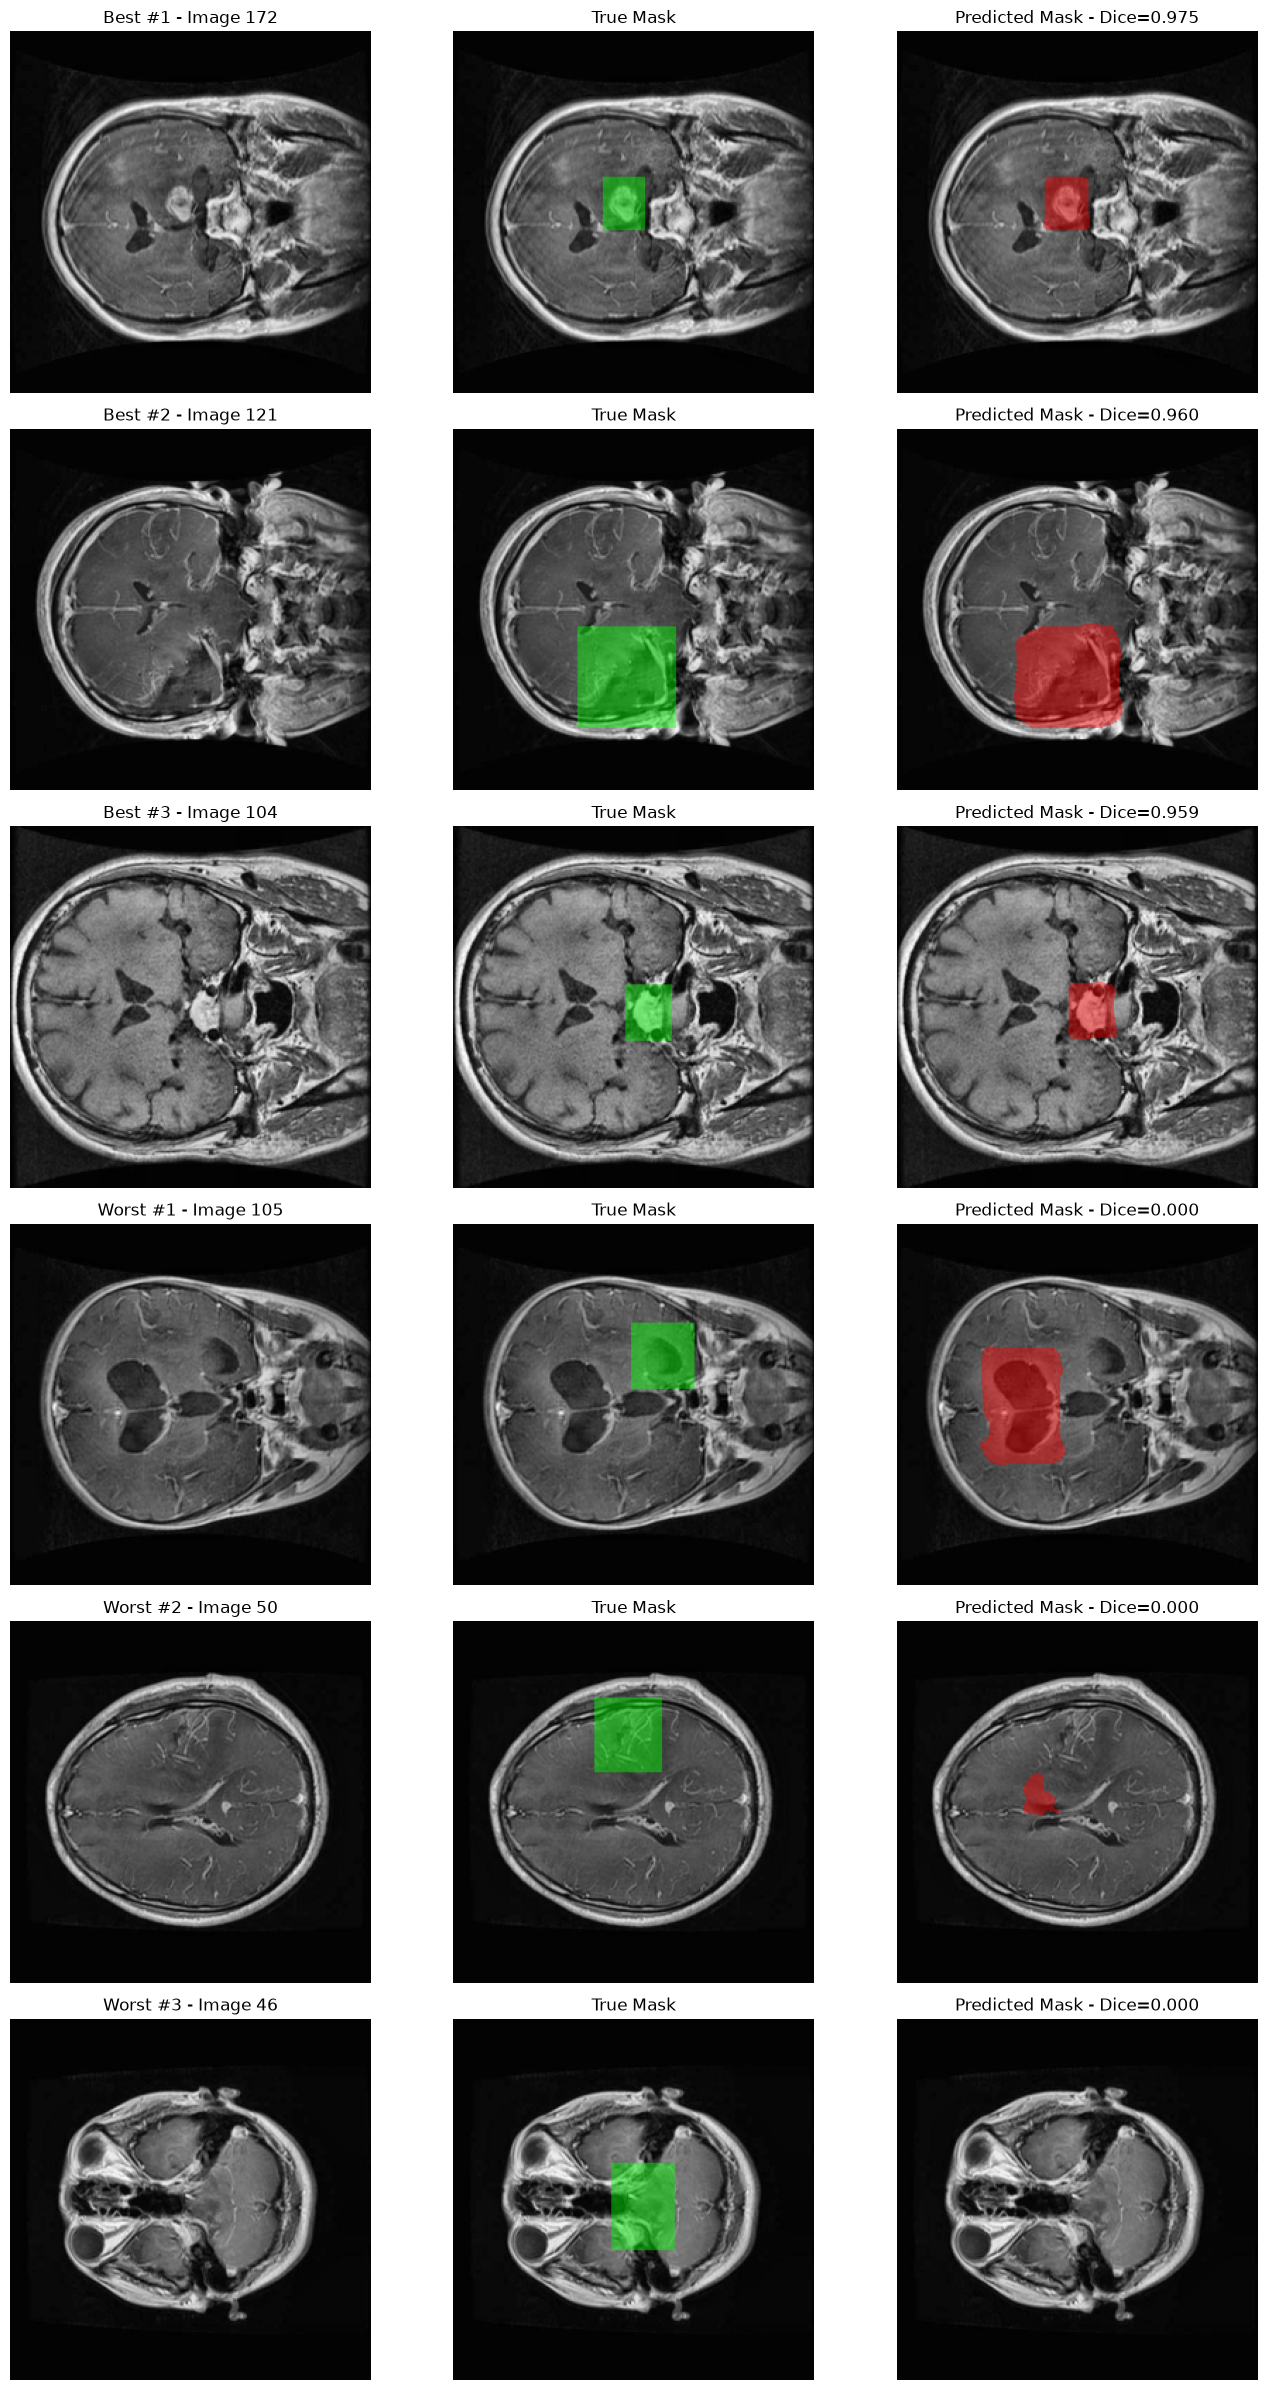

In [40]:
import matplotlib.pyplot as plt
import numpy as np

best_idx = np.argsort(clean_dice_scores)[-3:][::-1]
worst_idx = np.argsort(clean_dice_scores)[:3]

indices = list(best_idx) + list(worst_idx)
titles = [f"Best #{i+1}" for i in range(3)] + [f"Worst #{i+1}" for i in range(3)]

def make_overlay(mask, color=(0, 1, 0), alpha=0.45):
    h, w = mask.shape
    overlay = np.zeros((h, w, 4), dtype=np.float32)
    overlay[..., 0] = color[0]
    overlay[..., 1] = color[1]
    overlay[..., 2] = color[2]
    overlay[..., 3] = mask * alpha
    return overlay


plt.figure(figsize=(14, 4 * len(indices)))

for row, (idx, label) in enumerate(zip(indices, titles)):
    img = X_test[idx]
    true_mask = y_test[idx].squeeze()
    pred_mask = pred_masks_clean[idx]
    dice = clean_dice_scores[idx]

    true_overlay = make_overlay(true_mask, color=(0, 1, 0), alpha=0.45)
    pred_overlay = make_overlay(pred_mask, color=(1, 0, 0), alpha=0.45)


    plt.subplot(len(indices), 3, 3 * row + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{label} - Image {idx}")
    plt.axis("off")

    plt.subplot(len(indices), 3, 3 * row + 2)
    plt.imshow(img, cmap="gray")
    plt.imshow(true_overlay)
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(len(indices), 3, 3 * row + 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(pred_overlay)
    plt.title(f"Predicted Mask - Dice={dice:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Results & Next Steps

### Observations
- Post-processing provides a small but consistent improvement across all metrics, suggesting many predicted masks contain noisy isolated regions that get removed.
- Recall is higher than Precision in both settings, meaning the model tends to **over-segment** slightly.
- The relatively high standard deviation (~0.24) across samples indicates performance varies significantly between images, which is common in segmentation tasks with diverse or difficult samples.
- A low optimal threshold (0.05) suggests the model's sigmoid outputs are skewed toward lower confidence, pointing to class imbalance during training or a benefit from adjusting the focal loss alpha parameter.

### Potential Improvements
- **Lower alpha in focal loss** — since the optimal threshold is very low (0.05), the model may be under-confident on foreground pixels.
- **Test-time augmentation (TTA)** — average predictions over multiple augmented versions of each test image to reduce variance.
- **Harder augmentation** — the high std deviation suggests some images were much harder, a more aggressive augmentation could improve robustness.